# Notebook 08 — Detección de trayectorias con YOLO (Etapa 1)

## Idea

Primera etapa del pipeline _detect-then-segment_ de `plan/detection-segmentation-guide.md`:
un detector localiza cada traza del kymógrafo como una **caja**. Se comparan dos detectores
sobre el mismo dataset exportado por `src/axonal_tracking/etiquetas_deteccion.py`:

1. **Baseline clásico** (sin aprendizaje): umbral + componentes conexas (guía §4.2). Es el
   piso que YOLO debe superar (requisito 5.4: comparación clásico-vs-ML).
2. **YOLO fine-tuneado** `yolov8n` (guía §4.3).

**Dos clases**: `movil` (0) y `estatico` (1). Este notebook prueba la variante _con_ estáticas
para ver cómo se comporta; para movers-only, re-exportar con `etiquetar_estaticos=False` y
volver a correr (ver la discusión sobre etiquetar estáticas vs. tratarlas como fondo). **Mirar
las métricas por clase**, no sólo el mAP global: si `estatico` sale ruidosa, es la señal.

Requisitos: correr `scripts/exportar_etiquetas_deteccion.py` antes (genera `kymograph_detection.yaml`).


---

## 0. Setup


In [9]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import yaml

sys.path.append(str(Path("..") / "src"))
from axonal_tracking import etiquetas_deteccion as ed

RAIZ = Path("..").resolve()
DATASETS = RAIZ / "datasets"
YOLO_DIR = DATASETS / "yolo_detection"
DATA_YAML = YOLO_DIR / "kymograph_detection.yaml"

assert (
    DATA_YAML.exists()
), f"No existe {DATA_YAML}. Correr scripts/exportar_etiquetas_deteccion.py primero."
print("data-config:", DATA_YAML)
print(yaml.safe_load(DATA_YAML.read_text()))

data-config: /Users/alejandrovalle/Desktop/Posgrado/CEIA/axonal-tracking/datasets/yolo_detection/kymograph_detection.yaml
{'path': '/Users/alejandrovalle/Desktop/Posgrado/CEIA/axonal-tracking/datasets/yolo_detection', 'train': 'images/train', 'val': 'images/val', 'test': 'images/test', 'names': {0: 'movil', 1: 'estatico'}}


---

## 1. Baseline clásico — umbral + componentes conexas (guía §4.2)

Detector **sin aprendizaje**: se binariza el kymógrafo por umbral, se conectan los píxeles
brillantes con un cierre morfológico, y cada componente conexa da una caja candidata. Es
agnóstico a clase (sólo dice "acá hay una traza"), y sirve de piso: si YOLO no le gana, algo
está mal antes de la Etapa 2. Se evalúa con recall/precision/F-beta (beta>1 pondera recall,
mismo criterio que `roi_detect.py` de synthkymo).


In [10]:
from skimage.filters import threshold_otsu
from skimage.morphology import closing, disk
from skimage.measure import label, regionprops


def detectar_clasico(kymo, cierre_radio=1, area_min=12):
    """Baseline sin aprendizaje: umbral de Otsu (adaptativo por imagen) + componentes
    conexas -> cajas (x1, y1, x2, y2), agnóstico a clase. Es el piso que YOLO debe superar
    (guía §4.2). Otsu se banca la variedad de brillo entre configs; un percentil global no.
    """
    a = np.asarray(kymo, dtype=float)
    if a.ndim == 3:
        a = a[..., 0]
    mask = closing(a > threshold_otsu(a), disk(cierre_radio))
    cajas = []
    for r in regionprops(label(mask)):
        if r.area < area_min:
            continue
        minr, minc, maxr, maxc = r.bbox
        cajas.append((float(minc), float(minr), float(maxc), float(maxr)))
    return cajas


def iou(a, b):
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(ix2 - ix1, 0.0) * max(iy2 - iy1, 0.0)
    union = (a[2] - a[0]) * (a[3] - a[1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter
    return inter / union if union > 0 else 0.0


def evaluar_deteccion(pred, gt, iou_thr=0.3, beta=2.0):
    """recall/precision/F-beta por matching greedy de cajas predichas a GT por IoU."""
    matched = set()
    tp = 0
    for p in pred:
        mejor_j, mejor_iou = -1, iou_thr
        for j, g in enumerate(gt):
            if j in matched:
                continue
            v = iou(p, g)
            if v >= mejor_iou:
                mejor_j, mejor_iou = j, v
        if mejor_j >= 0:
            matched.add(mejor_j)
            tp += 1
    recall = tp / max(len(gt), 1)
    precision = tp / max(len(pred), 1)
    fb = (1 + beta**2) * precision * recall / max(beta**2 * precision + recall, 1e-9)
    return {
        "recall": recall,
        "precision": precision,
        "f_beta": fb,
        "n_pred": len(pred),
        "n_gt": len(gt),
    }

In [11]:
def gt_cajas(kymo, positions, pixel_scale_um):
    """Cajas ground-truth (ambas clases) de una escena, reusando el exportador."""
    T, L = np.asarray(kymo).shape[:2]
    return [
        (c.x1, c.y1, c.x2, c.y2)
        for c in ed.cajas_desde_positions(positions, pixel_scale_um, (T, L))
    ]


filas = []
for s in sorted((DATASETS / "test").glob("sample_*")):
    kymo = ed._leer_kymografo_tif(s / "kymograph.tif")
    positions = pd.read_csv(s / "positions.csv")
    px = float(
        yaml.safe_load((s / "config.yaml").read_text())["general"]["pixel_scale_um"]
    )
    filas.append(
        evaluar_deteccion(detectar_clasico(kymo), gt_cajas(kymo, positions, px))
    )

clasico = pd.DataFrame(filas)
print("Baseline clásico sobre test (media):")
print(clasico[["recall", "precision", "f_beta"]].mean().round(3).to_string())

Baseline clásico sobre test (media):
recall       0.361
precision    0.540
f_beta       0.381


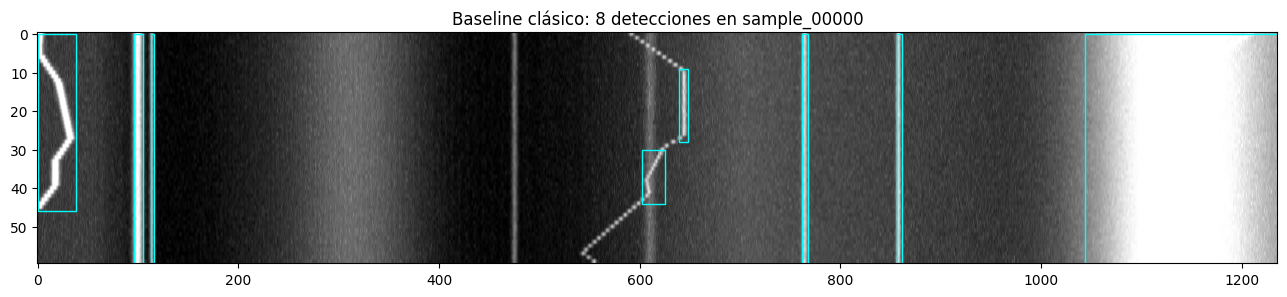

In [12]:
# inspección cualitativa: cajas del baseline sobre una muestra
s = sorted((DATASETS / "test").glob("sample_*"))[0]
kymo = np.asarray(ed._leer_kymografo_tif(s / "kymograph.tif"))
if kymo.ndim == 3:
    kymo = kymo[..., 0]
pred = detectar_clasico(kymo)

fig, ax = plt.subplots(figsize=(16, 3))
ax.imshow(
    kymo,
    cmap="gray",
    aspect="auto",
    vmin=np.percentile(kymo, 1),
    vmax=np.percentile(kymo, 99.5),
)
for x1, y1, x2, y2 in pred:
    ax.add_patch(
        Rectangle((x1, y1), x2 - x1, y2 - y1, edgecolor="cyan", facecolor="none", lw=1)
    )
ax.set_title(f"Baseline clásico: {len(pred)} detecciones en {s.name}")
plt.show()

---

## 2. Fine-tune YOLO `yolov8n` (guía §4.3)

`yolov8n` = variante "nano", la más chica: los kymógrafos son de baja complejidad visual y
pocas clases, así que un backbone grande cuesta presupuesto sin ganar mucho. Los kymógrafos son
**anchos y bajos** (~60×900), lejos del cuadrado que YOLO asume por defecto -> `imgsz` y
`rect=True` (batches rectangulares, menos padding) son perillas a ajustar. Correr en GPU si se
puede; con `epochs=100` en CPU/MPS puede tardar -- bajar `epochs` para una prueba rápida.

**Nota**: el run escribe pesos/plots en `results/yolo/` -- conviene agregar `results/` al
`.gitignore` si no está.


In [13]:
from ultralytics import YOLO

modelo = YOLO("yolov8n.pt")  # checkpoint COCO preentrenado

In [14]:
resultados = modelo.train(
    data=str(DATA_YAML),
    epochs=100,  # bajar para prueba rápida
    imgsz=960,  # kymógrafos ~60x900; ajustar segun aspecto
    rect=True,  # batches rectangulares (menos padding en imagenes no cuadradas)
    batch=16,
    patience=20,  # early stopping si val no mejora
    project=str(RAIZ / "results" / "yolo"),
    name="deteccion_v1",
    device="mps",  # descomentar/forzar si hace falta (Mac); si no, autodetecta
)
print("mejor modelo:", resultados.save_dir)

New https://pypi.org/project/ultralytics/8.4.115 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.101 🚀 Python-3.13.2 torch-2.12.0 MPS (Apple M5 Pro)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/alejandrovalle/Desktop/Posgrado/CEIA/axonal-tracking/datasets/yolo_detection/kymograph_detection.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=

---

## 3. Evaluar — mAP global y **por clase** (guía §4.4)

Lo importante acá no es sólo el mAP global sino la separación **`movil` vs `estatico`**: si
`estatico` sale mucho peor que `movil`, es la inconsistencia de etiquetar estáticas GT mientras
los artefactos estáticos quedan como fondo (misma pinta, etiqueta opuesta) -> señal para probar
la variante movers-only.


In [15]:
metricas = modelo.val(data=str(DATA_YAML), split="test")
print("mAP50-95:", round(float(metricas.box.map), 3))
print("mAP50   :", round(float(metricas.box.map50), 3))
print("por clase (mAP50-95):")
for i, ap in zip(
    metricas.box.ap_class_index, metricas.box.maps[metricas.box.ap_class_index]
):
    print(f"  {modelo.names[int(i)]:10s}: {float(ap):.3f}")

Ultralytics 8.4.101 🚀 Python-3.13.2 torch-2.12.0 CPU (Apple M5 Pro)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 299.3±80.0 MB/s, size: 55.4 KB)
val: Scanning /Users/alejandrovalle/Desktop/Posgrado/CEIA/axonal-tracking/datasets/yolo_detection/labels/test... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 6.3Kit/s 0.0s
val: New cache created: /Users/alejandrovalle/Desktop/Posgrado/CEIA/axonal-tracking/datasets/yolo_detection/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.1it/s 3.4s0.6s
                   all        100       1200      0.946      0.891      0.937      0.812
                 movil        100        697      0.941      0.859      0.923      0.794
              estatico        100        503       0.95      0.922      0.951       0.83
Speed: 0.0ms preprocess, 27.6ms inference, 0.0ms loss, 0.

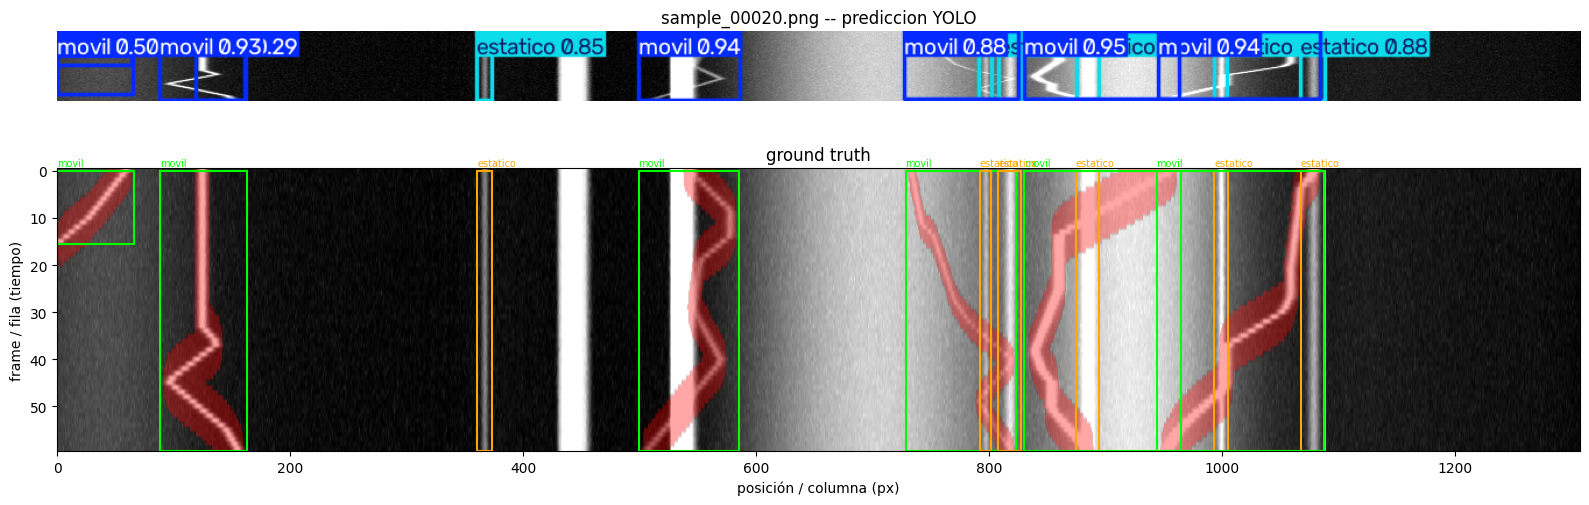

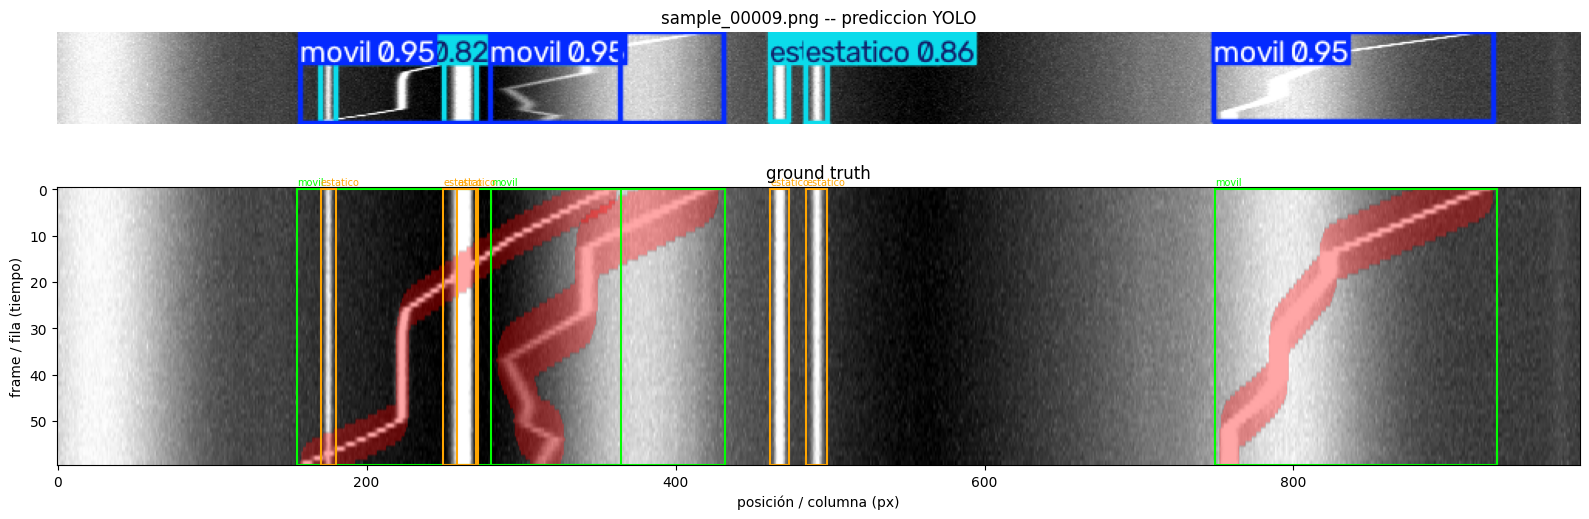

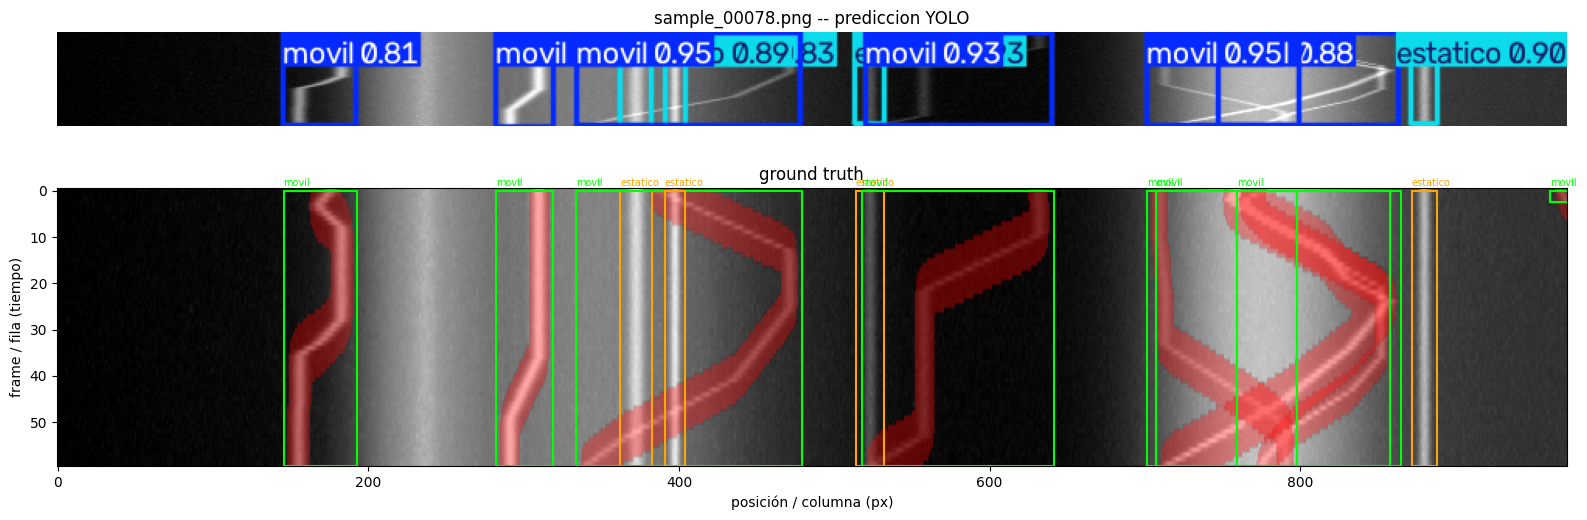

In [16]:
# inferencia cualitativa: prediccion (arriba) vs. ground truth (abajo), por muestra
import random

test_imgs = sorted((YOLO_DIR / "images" / "test").glob("*.png"))
muestras = random.sample(test_imgs, min(3, len(test_imgs)))

for ruta in muestras:
    # OJO: predecir de a UNA imagen, NO pasar la lista completa a predict().
    # Los kymografos tienen anchos muy distintos entre muestras (verificado: 690 a
    # 1453px en este dataset). Si se batchean varias juntas en una sola llamada,
    # ultralytics las redimensiona/rellena a un lienzo compartido -> distorsiona las
    # mas angostas y produce cajas degeneradas (altura ~0px) y basura de baja
    # confianza. Verificado directamente: la misma imagen sola da cajas limpias
    # que calzan con el ground truth; en batch de 3, la misma imagen paso de 6 a
    # 14 cajas "movil", varias con altura 0.
    r = modelo.predict(str(ruta), imgsz=960, conf=0.25, verbose=False)[0]

    fig, axes = plt.subplots(2, 1, figsize=(16, 6))

    axes[0].imshow(r.plot()[..., ::-1])  # ultralytics devuelve BGR
    axes[0].set_title(f"{ruta.name} -- prediccion YOLO")
    axes[0].axis("off")

    s = DATASETS / "test" / ruta.stem
    kymo = ed._leer_kymografo_tif(s / "kymograph.tif")
    positions = pd.read_csv(s / "positions.csv")
    px = float(
        yaml.safe_load((s / "config.yaml").read_text())["general"]["pixel_scale_um"]
    )
    ed.plot_muestra_anotada(kymo, positions, px, ax=axes[1])
    axes[1].set_title("ground truth")

    plt.tight_layout()
    plt.show()

---

## 4. Comparación clásico vs. YOLO + conclusión

- Tabla clásico vs. YOLO (recall/precision/F-beta y mAP) sobre el **mismo** test.
- Cualitativo: dónde falla cada uno (trazas tenues, cruces, densidad) -- el "por qué" importa
  tanto como el número (requisito 5.4).
- Decisión pendiente: **¿dos clases o movers-only?** Este notebook corre la variante de 2
  clases; para la comparación honesta, re-exportar con `etiquetar_estaticos=False`, re-entrenar,
  y comparar la detección de **`movil`** entre ambas (mismo detector, mismas imágenes, sólo
  cambian las etiquetas).

Completar con los números una vez entrenado.
